# Notebook for ETZ Dataset Exploration

In [ ]:
# Installing libraries
!pip install nibabel
!pip install pandas
!pip install matplotlib
!pip install scikit-image
!pip install opencv-python

In [ ]:
# Import libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib

plt.style.use('ggplot')


## Open and Visualize some CT Scans + Annotations

In [4]:
# Uniform images 
inputpath = '/wecare/projects/Slicer_ready_data/Original Patient Data/Uniform_scaling/Images'
uniform_images = os.listdir(inputpath)
print(uniform_images)
print("Nr. of CT scans:", len(uniform_images))

# Uniform image labels
inputpath = '/wecare/projects/Slicer_ready_data/Original Patient Data/Uniform_scaling/NewLabels'
uniform_annotations = os.listdir(inputpath)
print(uniform_annotations)
print("Nr. of annotation files:", len(uniform_annotations))

# Match images and labels
annotated_uniform_images = [image for image in uniform_images if f"{image[0:9]}.nii" in uniform_annotations]
annotated_uniform_labels = [f"{image[0:9]}.nii" for image in annotated_uniform_images]
annotated_uniform_images.extend(['CTP100_001_0000.nii', 'CTP102_001_0000.nii'])
annotated_uniform_labels.extend(['CTP100_001.nii', 'CTP102_001.nii'])
print("Nr. of matching scan and label files:", len(annotated_uniform_images))


['CTP27_001_0000.nii', 'CTP74_001_0000.nii', 'CTP81_001_0000.nii', 'CTP64_002_0000.nii', 'CTP26_001_0000.nii', 'CTP75_001_0000.nii', 'CTP67_002_0000.nii', 'CTP82_001_0000.nii', 'CTP34_002_0000.nii', 'CTP77_001_0000.nii', 'CTP92_002_0000.nii', 'CTP24_001_0000.nii', 'CTP76_001_0000.nii', 'CTP35_002_0000.nii', 'CTP83_001_0000.nii', 'CTP20_001_0000.nii', 'CTP73_001_0000.nii', 'CTP86_001_0000.nii', 'CTP59_001_0000.nii', 'CTP58_001_0000.nii', 'CTP87_001_0000.nii', 'CTP21_001_0000.nii', 'CTP85_001_0000.nii', 'CTP70_001_0000.nii', 'CTP71_001_0000.nii', 'CTP22_001_0000.nii', 'CTP100_001_0000.nii', 'CTP29_001_0000.nii', 'CTP50_001_0000.nii', 'CTP02_001_0000.nii', 'CTP51_001_0000.nii', 'CTP28_001_0000.nii', 'CTP53_001_0000.nii', 'CTP79_001_0000.nii', 'CTP102_001_0000.nii', 'CTP78_001_0000.nii', 'CTP52_001_0000.nii', 'CTP04_001_0000.nii', 'CTP57_001_0000.nii', 'CTP56_001_0000.nii', 'CTP89_001_0000.nii', 'CTP15_002_0000.nii', 'CTP46_002_0000.nii', 'CTP07_001_0000.nii', 'CTP55_001_0000.nii', 'CTP44_

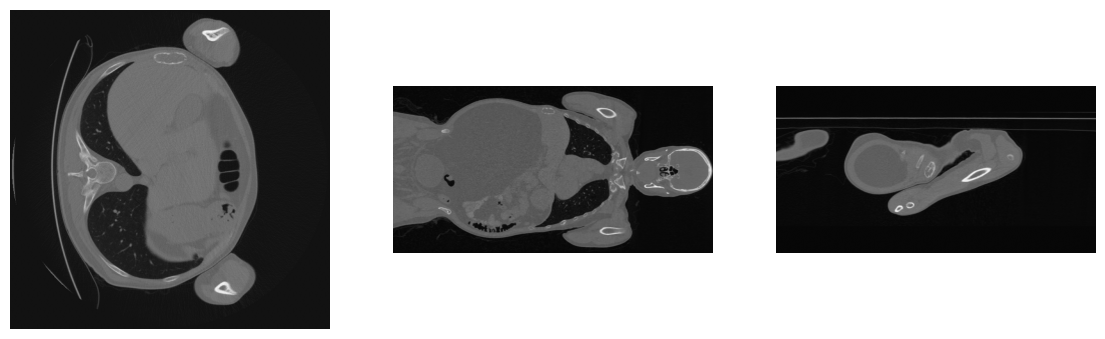

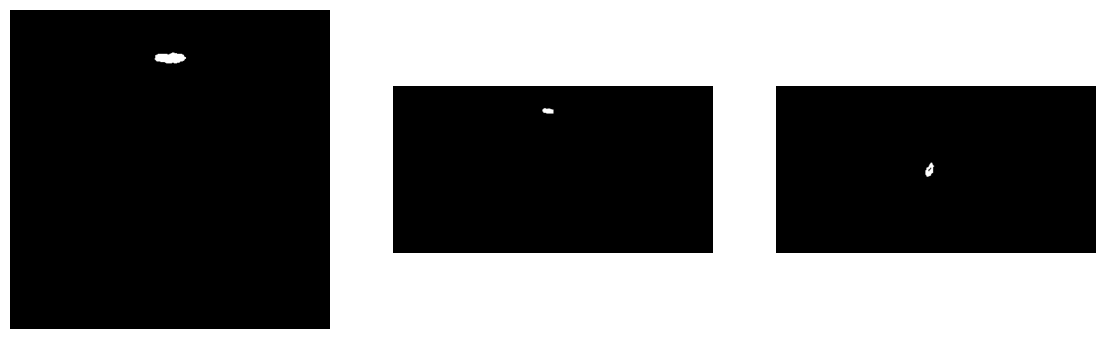

In [6]:
# Display some example CT scan slices

img_inputpath = '/wecare/projects/Slicer_ready_data/Original Patient Data/Uniform_scaling/Images/'
lab_inputpath = '/wecare/projects/Slicer_ready_data/Original Patient Data/Uniform_scaling/NewLabels/'

# Image
img = annotated_uniform_images[0]
img = nib.load(img_inputpath+img)
#print(img.header) # pixdim = 1 1 1 so uniform scaling!
img_arr = img.get_fdata()
# print(img_arr.shape)
# bbox for large lesion for subject 0 (CPT27) = 68, 216, 444, 86, 275, 480
axial = img_arr[:,:,460]
coronal = img_arr[:,250,:]
sagittal = img_arr[70,:,:]
cross_sections = [axial, coronal, sagittal]
fig, axes = plt.subplots(1, 3, figsize=(14, 21))
for i, s in enumerate(cross_sections):
    axes[i].imshow(s, cmap='gray')
    axes[i].axis('off')


# Corresponding labels
lab = annotated_uniform_labels[0]
lab = nib.load(lab_inputpath+lab)
lab_arr = lab.get_fdata()
# print(lab_arr.shape)
# bbox for large lesion for subject 0 (CPT27) = 68, 216, 444, 86, 275, 480
axial = lab_arr[:,:,460]
coronal = lab_arr[:,250,:]
sagittal = lab_arr[70,:,:]
cross_sections = [axial, coronal, sagittal]
fig, axes = plt.subplots(1, 3, figsize=(14, 21))
for i, s in enumerate(cross_sections):
    axes[i].imshow(s, cmap='gray')
    axes[i].axis('off')

plt.show()


## Explore Lesion Properties + Distributions and apply Sampling to resolve Data Imbalance

In [10]:
# Original datasplit
train = range(0,74)
val = range(74, 89)
test = range(89,104)

# # Cross validation datasplit
# train = (2, 4, 7, 100, 15, 21, 22, 24, 26, 27, 28,
#                       29, 31, 32, 33, 34, 36, 37, 40, 41, 42, 43,
#                       46, 47, 48, 49, 51, 52, 53, 55, 56, 57, 58, 
#                       60, 62, 63, 64, 65, 66, 67, 69, 71, 73, 74,
#                       75, 76, 77, 78, 79, 86, 89, 91, 92, 93, 94, 
#                       95, 97, 99)
# val = (20, 38, 39, 44, 59, 61, 68, 70, 82, 85) 
# test = (102, 10, 12, 35, 45, 81, 83, 87, 90, 98)

In [16]:
# Explore all lesion sizes (min, max, quartiles, distributions per datasplit)
lesion_properties = pd.read_csv("lesion_properties.csv", dtype={'label': int})
lesion_properties["nr_axial_slices"] = lesion_properties["bbox-5"] - lesion_properties["bbox-2"]
lesion_properties["subject_nr"] = [int(subject[3:6]) for subject in lesion_properties["Subject"]]
lesion_properties.sort_values(by="subject_nr", inplace=True)
display(lesion_properties.head())
print("Total number of axial slices:", sum(lesion_properties["nr_axial_slices"])) 
print("Total number of unique participants:", lesion_properties.nunique()["subject_nr"])

print("Min. area:", min(lesion_properties['area']))
print("Max. area:", max(lesion_properties['area']))
q1 = np.quantile(lesion_properties['area'], .25)
q2 = np.quantile(lesion_properties['area'], .5)
q3 = np.quantile(lesion_properties['area'], .75)
print("Quartiles:", q1, q2, q3)

# Train split
train_df = lesion_properties[lesion_properties["subject_nr"].isin(train)]
print("\nNumber of training set subjects:", train_df.nunique()["subject_nr"])
print("Number of lesions:", len(train_df))
q1 = np.quantile(train_df['area'], .25)
q2 = np.quantile(train_df['area'], .5)
q3 = np.quantile(train_df['area'], .75)
print("Quartiles:", q1, q2, q3)

# Val split
val_df = lesion_properties[lesion_properties["subject_nr"].isin(val)]
print("\nNumber of validation set subjects:",val_df.nunique()["subject_nr"])
print("Number of lesions:", len(val_df))
q1 = np.quantile(val_df['area'], .25)
q2 = np.quantile(val_df['area'], .5)
q3 = np.quantile(val_df['area'], .75)
print("Quartiles:", q1, q2, q3)

# Test split
test_df = lesion_properties[lesion_properties["subject_nr"].isin(test)]
print("\nNumber of testing set subjects:", test_df.nunique()["subject_nr"])
print("Number of lesions:", len(test_df))
q1 = np.quantile(test_df['area'], .25)
q2 = np.quantile(test_df['area'], .5)
q3 = np.quantile(test_df['area'], .75)
print("Quartiles:", q1, q2, q3)


,Subject,label,area,bbox-0,bbox-1,bbox-2,bbox-3,bbox-4,bbox-5,nr_axial_slices,subject_nr
314,CTP002_001,1,471.0,237,227,1558,248,239,1565,7,2
392,CTP004_001,4,388.0,287,176,1401,307,185,1406,5,4
394,CTP004_001,6,6358.0,344,167,1308,386,207,1341,33,4
389,CTP004_001,1,450.0,186,185,1060,195,199,1066,6,4
393,CTP004_001,5,302.0,288,257,1523,300,264,1529,6,4


Total number of axial slices: 7901
Total number of unique participants: 78
Min. area: 26.0
Max. area: 166477.0
Quartiles: 199.5 472.0 1537.5

Number of training set subjects: 54
Number of lesions: 527
Quartiles: 190.0 453.0 1430.5

Number of validation set subjects: 12
Number of lesions: 79
Quartiles: 237.0 511.0 1593.0

Number of testing set subjects: 12
Number of lesions: 77
Quartiles: 193.0 593.0 2076.0


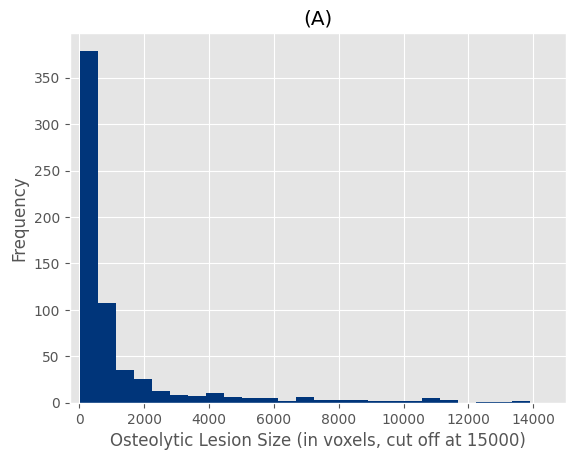

In [9]:
# Histogram of lesion sizes
plt.figure()
plt.hist(lesion_properties['area'], bins=300, color="#00357A")
plt.xlabel("Osteolytic Lesion Size (in voxels, cut off at 15000)")
plt.xlim((-300,15000))
plt.ylabel("Frequency")
plt.title('(A)')
plt.savefig("/wecare/home/lotte/Thesis/to_export/hist.png", bbox_inches='tight')
plt.show()

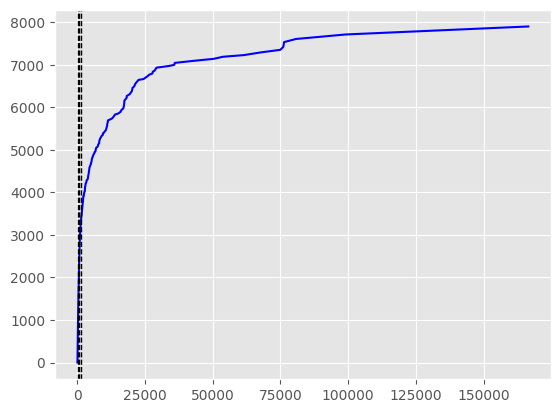

In [17]:
# Inspect imbalance between number of slices for small and large lesions

lesion_sizes = list(lesion_properties['area'])
nr_slices = list(lesion_properties['nr_axial_slices'])

table = {'sizes':lesion_sizes, 'slices':nr_slices}
table = pd.DataFrame(table)
table = table.sort_values(by=['sizes']).reset_index(drop=True)
table['cumul_slices'] = table['slices'].cumsum()

q1 = np.quantile(lesion_sizes, .25)
q2 = np.quantile(lesion_sizes, .5)
q3 = np.quantile(lesion_sizes, .75)

plt.figure()
plt.plot(table['sizes'], table['cumul_slices'], '-b')
plt.axvline(q1, linestyle='--', color='black', linewidth=1)
plt.axvline(q2, linestyle='--', color='black', linewidth=1)
plt.axvline(q3, linestyle='--', color='black', linewidth=1)
plt.show()

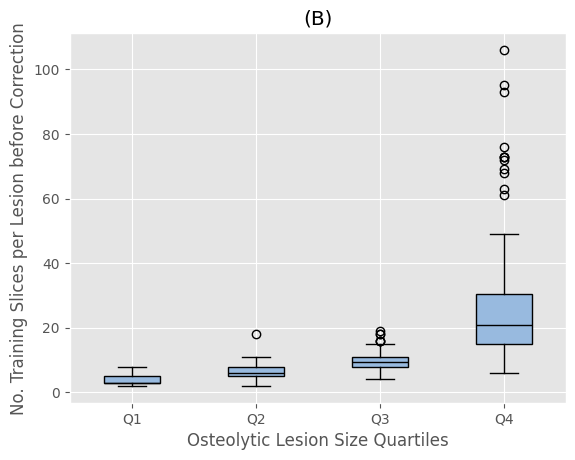

Total nr. of slices per size quartile:


quartiles
q1     698
q2    1114
q3    1634
q4    4455
Name: slices, dtype: int64

Average nr. of slices per lesion in each size quartile:


quartiles
q1     4.081871
q2     6.514620
q3     9.611765
q4    26.052632
Name: slices, dtype: float64

Std. in nr. of slices per lesion in each size quartile:


quartiles
q1     1.550813
q2     2.056144
q3     2.820442
q4    17.573129
Name: slices, dtype: float64

In [20]:
size_groups = []
for size in lesion_sizes:
    if size <= q1:
        size_groups.append('q1')
        continue
    elif size <= q2:
        size_groups.append('q2')
        continue
    elif size <= q3:
        size_groups.append('q3')
        continue
    elif size > q3:
        size_groups.append('q4')
        continue
lesion_properties['quartile'] = size_groups

table = {'sizes':lesion_sizes, 'slices':nr_slices, 'quartiles':size_groups}
table = pd.DataFrame(table)

grouped_data = [
    list(table[table['quartiles']=='q1']['slices']),
    list(table[table['quartiles']=='q2']['slices']),
    list(table[table['quartiles']=='q3']['slices']),
    list(table[table['quartiles']=='q4']['slices']),
]

labels = ['Q1', 'Q2', 'Q3', 'Q4']
medianprops = dict(linestyle='-', linewidth=1, color='black')

plt.figure()
bplot = plt.boxplot(grouped_data, patch_artist=True, tick_labels=labels, medianprops=medianprops)
for patch in bplot['boxes']:
    patch.set_facecolor("#98badf")
plt.xlabel("Osteolytic Lesion Size Quartiles")
plt.ylabel("No. Training Slices per Lesion before Correction")
plt.title('(B)')
plt.savefig("/wecare/home/lotte/Thesis/to_export/before_correction.png", bbox_inches='tight')
plt.show()

print("Total nr. of slices per size quartile:")
total_nr_slices_per_group = table.groupby('quartiles')['slices'].sum()
display(total_nr_slices_per_group)

print("Average nr. of slices per lesion in each size quartile:")
total_nr_slices_per_group = table.groupby('quartiles')['slices'].mean()
display(total_nr_slices_per_group)

print("Std. in nr. of slices per lesion in each size quartile:")
total_nr_slices_per_group = table.groupby('quartiles')['slices'].std()
display(total_nr_slices_per_group)



In [ ]:
# Sample from the training data to counter data imbalance

slice_props = pd.read_csv('/wecare/home/lotte/Thesis/CODE/ETZ/cross_slice_properties.csv', dtype={'scan_nr': str, 'label': int})

splits = [] # for each image determine the datasplit it is in
for nr in list(slice_props['scan_nr']):
    if int(nr) in train:
        splits.append('train')
        continue
    elif int(nr) in val:
        splits.append('val')
        continue
    elif int(nr) in test:
        splits.append('test')
        continue

size_groups = [] # for each lesion in each image determine the size quartile it is in
for scan_nr, take, label in zip(list(slice_props['scan_nr']), list(slice_props['take']), list(slice_props['label'])):
    Subject = f'CTP0{scan_nr}_00{take}' if len(scan_nr) == 2 else f'CTP{scan_nr}_00{take}'
    lesion_area = lesion_properties.loc[(lesion_properties['Subject']==Subject) & (lesion_properties['label']==label), 'area'].iloc[0]
    if lesion_area <= q1:
        size_groups.append('q1')
        continue
    elif lesion_area <= q2:
        size_groups.append('q2')
        continue
    elif lesion_area <= q3:
        size_groups.append('q3')
        continue
    elif lesion_area > q3:
        size_groups.append('q4')
        continue

slice_props['split'] = splits
slice_props['size_quartile'] = size_groups
slice_props['lesion_id'] = (slice_props['scan_nr'].astype(str) + '_' + slice_props['take'].astype(str) + '_' + slice_props['label'].astype(str))
slice_props['slice_id'] = (slice_props['scan_nr'].astype(str) + '_' + slice_props['take'].astype(str) + '_' + slice_props['slice_index'].astype(str))

display(slice_props.head())


,Unnamed: 0,scan_nr,take,view,slice_index,index,label,area,centroid-0,centroid-1,bbox-0,bbox-1,bbox-2,bbox-3,width,height,split,size_quartile,lesion_id,slice_id
0,0,02,1,top,1558,0.0,1,47.0,244.042553,232.723404,242.0,228.0,248.0,238.0,459,459,train,q2,02_1_1,02_1_1558
1,1,02,1,top,1559,0.0,1,60.0,243.633333,232.766667,241.0,228.0,248.0,239.0,459,459,train,q2,02_1_1,02_1_1559
2,2,02,1,top,1560,0.0,1,90.0,242.200000,232.888889,238.0,227.0,248.0,239.0,459,459,train,q2,02_1_1,02_1_1560
3,3,02,1,top,1561,0.0,1,91.0,241.967033,232.868132,238.0,227.0,247.0,239.0,459,459,train,q2,02_1_1,02_1_1561
4,4,02,1,top,1562,0.0,1,90.0,241.666667,232.866667,237.0,227.0,247.0,239.0,459,459,train,q2,02_1_1,02_1_1562


In [ ]:
# Check distribution of Q1 lesions in the training data:

train_q1_slices = slice_props[(slice_props['split']=="train") & (slice_props['size_quartile']=='q1')]
print(len(train_q1_slices), "slices for Q1 lesions in training set")

splits = [] # for each lesion determine the datasplit it is in
for nr in list(lesion_properties['Subject']):
    nr = nr[3:6]
    if int(nr) in train:
        splits.append('train')
        continue
    elif int(nr) in val:
        splits.append('val')
        continue
    elif int(nr) in test:
        splits.append('test')
        continue
lesion_properties['split'] = splits

train_q1_lesions = lesion_properties[(lesion_properties['split']=="train") & (lesion_properties['quartile']=='q1')]
print(len(train_q1_lesions), "Q1 lesions in training set")
print(round(len(train_q1_slices)/len(train_q1_lesions), 2), "slices on averages per Q1 lesion")

display(lesion_properties.head())


547 slices for Q1 lesions in training set
136 Q1 lesions in training set
4.02 slices on averages per Q1 lesion


,Subject,label,area,bbox-0,bbox-1,bbox-2,bbox-3,bbox-4,bbox-5,nr_axial_slices,subject_nr,quartile,split
314,CTP002_001,1,471.0,237,227,1558,248,239,1565,7,2,q2,train
392,CTP004_001,4,388.0,287,176,1401,307,185,1406,5,4,q2,train
394,CTP004_001,6,6358.0,344,167,1308,386,207,1341,33,4,q4,train
389,CTP004_001,1,450.0,186,185,1060,195,199,1066,6,4,q2,train
393,CTP004_001,5,302.0,288,257,1523,300,264,1529,6,4,q2,train


In [25]:
# Check distribution of non-Q1 lesions in the training data:

train_large_lesions_slices = slice_props[(slice_props['split']=="train") & (slice_props['size_quartile']!='q1')]
print(len(train_large_lesions_slices), "slices for Q2-4 lesions in training set")

lesion_slices = (train_large_lesions_slices[['lesion_id', 'slice_id']].drop_duplicates())
sampled_slices = (lesion_slices.groupby('lesion_id', group_keys=False).apply(lambda x: x.sample(n=min(4,len(x)), random_state=42)))
sampled_df = slice_props[slice_props['slice_id'].isin(sampled_slices['slice_id'])].copy()

print(len(sampled_df), "slices remain after sampling")
df_duplicates = sampled_df[sampled_df.duplicated(subset='slice_id', keep=False)]

train_large_lesions = lesion_properties[(lesion_properties['split']=="train") & (lesion_properties['quartile']!='q1')]
print(len(train_large_lesions), "Q2-4 lesions in training set")
print(round(len(sampled_df)/len(train_large_lesions), 2), "slices on average per large lesion remain after sampling")

5366 slices for Q2-4 lesions in training set
2174 slices remain after sampling
391 Q2-4 lesions in training set
5.56 slices on average per large lesion remain after sampling


In [27]:
# Expand Q2-4 sampled data with the Q1 data

q1_slice_ids = train_q1_slices['slice_id'].unique()
q1_expanded = slice_props[slice_props['slice_id'].isin(q1_slice_ids)].copy()

final_sampled = pd.concat([q1_expanded, sampled_df], ignore_index=True)

lesion_slices_dic = {}
for lesion_id in list(final_sampled['lesion_id'].unique()):
    sub = final_sampled[final_sampled['lesion_id'] == lesion_id]
    lesion_slice_nr = len(sub)
    lesion_slices_dic[lesion_id] = lesion_slice_nr

nr_lesion_slices = [lesion_slices_dic[id] for id in final_sampled['lesion_id']]
final_sampled['nr_lesion_slices'] = nr_lesion_slices

display(final_sampled)

,Unnamed: 0,scan_nr,take,view,slice_index,index,label,area,centroid-0,centroid-1,...,bbox-1,bbox-2,bbox-3,width,height,split,size_quartile,lesion_id,slice_id,nr_lesion_slices
0,77,07,1,top,1215,0.0,5,17.0,234.352941,154.117647,...,152.0,237.0,157.0,458,458,train,q1,07_1_5,07_1_1215,5
1,78,07,1,top,1215,1.0,7,36.0,244.611111,158.138889,...,154.0,248.0,163.0,458,458,train,q2,07_1_7,07_1_1215,7
2,79,07,1,top,1216,0.0,5,21.0,234.190476,154.047619,...,152.0,237.0,157.0,458,458,train,q1,07_1_5,07_1_1216,5
3,80,07,1,top,1216,1.0,7,44.0,244.704545,157.840909,...,154.0,249.0,163.0,458,458,train,q2,07_1_7,07_1_1216,7
4,81,07,1,top,1217,0.0,5,17.0,234.352941,154.117647,...,152.0,237.0,157.0,458,458,train,q1,07_1_5,07_1_1217,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3007,5940,73,2,top,986,0.0,6,74.0,281.864865,172.959459,...,169.0,287.0,178.0,439,439,train,q3,73_2_6,73_2_986,5
3008,5942,73,2,top,988,0.0,8,48.0,335.104167,199.625000,...,196.0,339.0,204.0,439,439,train,q3,73_2_8,73_2_988,4
3009,5950,73,2,top,996,0.0,8,80.0,334.462500,198.637500,...,194.0,340.0,204.0,439,439,train,q3,73_2_8,73_2_996,4
3010,5951,73,2,top,997,0.0,8,35.0,336.085714,201.200000,...,199.0,340.0,205.0,439,439,train,q3,73_2_8,73_2_997,4


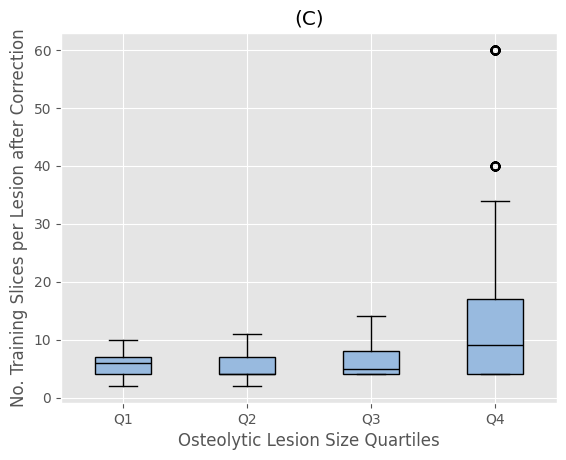

Average nr. of slices per lesion in each size quartile AFTER SAMPLING:


quartiles
q1     3736
q2     3698
q3     4333
q4    14619
Name: slices, dtype: int64

Std. in nr. of slices per lesion in each size quartile AFTER SAMPLING:


quartiles
q1     5.609610
q2     5.569277
q3     6.307132
q4    14.692462
Name: slices, dtype: float64

In [29]:
# Plot again to check if imbalance is attenuated (or resolved entirely)

table = {'quartiles':list(final_sampled['size_quartile']), 'slices':list(final_sampled['nr_lesion_slices'])}
table = pd.DataFrame(table)

grouped_data = [
    list(table[table['quartiles']=='q1']['slices']),
    list(table[table['quartiles']=='q2']['slices']),
    list(table[table['quartiles']=='q3']['slices']),
    list(table[table['quartiles']=='q4']['slices']),
]

plt.figure()
bplot = plt.boxplot(grouped_data, patch_artist=True, tick_labels=labels, medianprops=medianprops)
for patch in bplot['boxes']:
    patch.set_facecolor("#98badf")
plt.xlabel("Osteolytic Lesion Size Quartiles")
plt.ylabel("No. Training Slices per Lesion after Correction")
plt.title('(C)')
plt.savefig("/wecare/home/lotte/Thesis/to_export/after_correction.png", bbox_inches='tight')
plt.show()

print("Average nr. of slices per lesion in each size quartile AFTER SAMPLING:")
total_nr_slices_per_group = table.groupby('quartiles')['slices'].sum()
display(total_nr_slices_per_group)

print("Std. in nr. of slices per lesion in each size quartile AFTER SAMPLING:")
total_nr_slices_per_group = table.groupby('quartiles')['slices'].mean()
display(total_nr_slices_per_group)


In [ ]:
# Save training data sample
 
# final_sampled = final_sampled.drop(columns='Unnamed: 0')
final_sampled.to_csv('/wecare/home/lotte/Thesis/CODE/ETZ/sampled_data_properties.csv')

## Check Original Image Sizes and YOLOv5 Bone Detector Outputs

In [31]:
# Explore bone bounding box sizes

slices = pd.read_csv("/wecare/home/lotte/Thesis/CODE/ETZ/slice_properties.csv")
print("Smallest o.g. image width/height:", np.min(list(slices["width"])))
print("Largest o.g. image width/height:", np.max(list(slices["width"])))
print("Smallest lesion area in o.g. images:", np.min(list(slices["area"])))
print("Largest lesion area in o.g. images:", np.max(list(slices["area"])))
print("Mean lesion area in o.g. images:", np.mean(list(slices["area"])))

SF_slices = pd.read_csv("/wecare/home/lotte/Thesis/CODE/ETZ/slice_properties_SF_boneboxes.csv")
print("\nSmallest bone bounding box width:", np.min(list(SF_slices["width"])))
print("Largest bone bounding box width:", np.max(list(SF_slices["width"])))
print("Smallest bone bounding box height:", np.min(list(SF_slices["height"])))
print("Largest bone bounding box height:", np.max(list(SF_slices["height"])))

print("\nSmallest lesion area in bone bounding boxes from training subjects:", np.min(list(SF_slices["area"])))
print("Largest lesion area in bone bounding boxes from training subjects:", np.max(list(SF_slices["area"])))

Smallest o.g. image width/height: 384
Largest o.g. image width/height: 650
Smallest lesion area in o.g. images: 1.0
Largest lesion area in o.g. images: 3370.0
Mean lesion area in o.g. images: 331.1679534236173

Smallest bone bounding box width: 5
Largest bone bounding box width: 193
Smallest bone bounding box height: 5
Largest bone bounding box height: 152

Smallest lesion area in bone bounding boxes from training subjects: 1.0
Largest lesion area in bone bounding boxes from training subjects: 1798.0


Mean bone box width: 73.51960784313725
STD bone box width: 39.698465311732235
nQ1 bone box width: 43.25
Median bone box width: 66.0
Q3 bone box width: 105.0

Mean bone box height: 70.3785578747628
STD bone box height: 30.865421015953512
Q1 bone box height: 47.0
Median bone box height: 66.0
Q3 bone box height: 93.0

Mean bone box area: 5941.803921568628
STD bone box area: 4875.3734413293705
Q1 bone box area: 2301.0
Median bone box area: 4160.0
Q3 bone box area: 9115.5


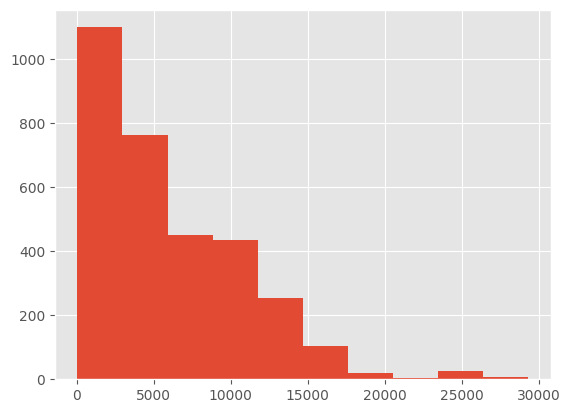

In [36]:
# Compute mean and quartiles
print("Mean bone box width:", np.mean(SF_slices["width"]))
print("STD bone box width:", np.std(SF_slices["width"]))
print("nQ1 bone box width:", np.quantile(SF_slices["width"], .25))
print("Median bone box width:", np.quantile(SF_slices["width"], .5))
print("Q3 bone box width:", np.quantile(SF_slices["width"], .75))

print("\nMean bone box height:", np.mean(SF_slices["height"]))
print("STD bone box height:", np.std(SF_slices["height"]))
print("Q1 bone box height:", np.quantile(SF_slices["height"], .25))
print("Median bone box height:", np.quantile(SF_slices["height"], .5))
print("Q3 bone box height:", np.quantile(SF_slices["height"], .75))

SF_slices["box_area"] = SF_slices["width"] * SF_slices["height"]
print("\nMean bone box area:", np.mean(SF_slices["box_area"]))
print("STD bone box area:", np.std(SF_slices["box_area"]))
print("Q1 bone box area:", np.quantile(SF_slices["box_area"], .25))
print("Median bone box area:", np.quantile(SF_slices["box_area"], .5))
print("Q3 bone box area:", np.quantile(SF_slices["box_area"], .75))

# And plot histograms of bone bounding box sizes
plt.figure()
plt.hist(SF_slices['box_area'])
plt.show()

